In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")

print("Iris Shape",iris.shape)
print("tips Shape",tips.shape)
print("Flights shape",flights.shape)

Iris Shape (150, 5)
tips Shape (244, 7)
Flights shape (144, 3)


## STEP1 : Line & Scatter Plots

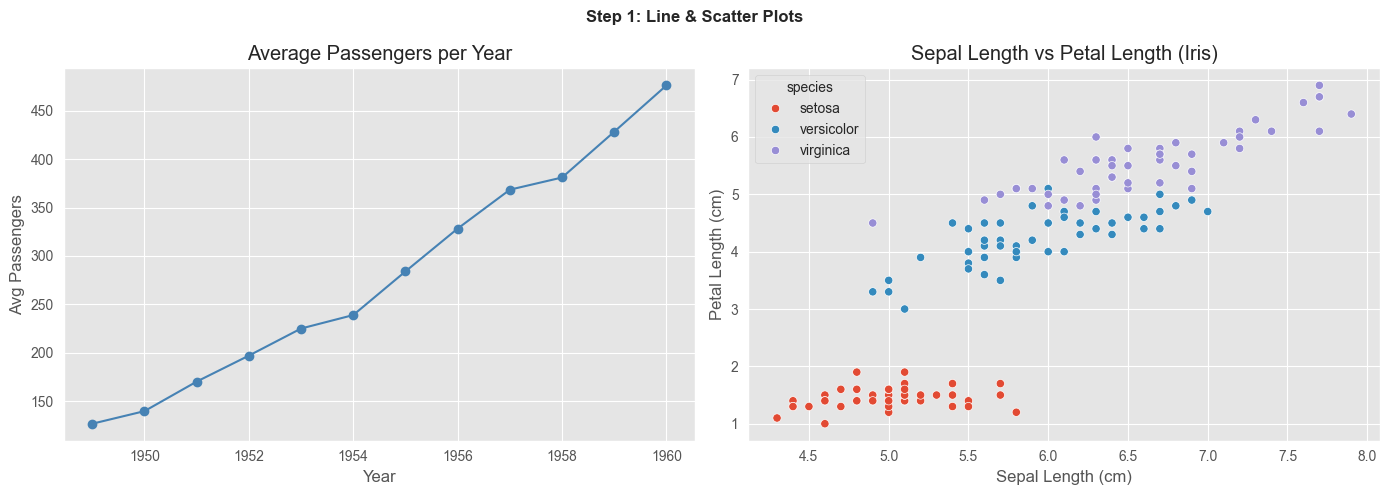

In [24]:
plt.style.use('ggplot')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 1: Line & Scatter Plots', fontweight='bold')

# --- Line Plot ---
avg_passengers = flights.groupby('year')['passengers'].mean()

axes[0].plot(avg_passengers.index, avg_passengers.values,
            marker='o', linestyle='-', color='steelblue')
axes[0].set_title('Average Passengers per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Passengers')
axes[0].grid(True)

# --- Scatter Plot ---
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',
                hue='species', ax=axes[1])
axes[1].set_title('Sepal Length vs Petal Length (Iris)')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## STEP2 : Styling & Cutomization

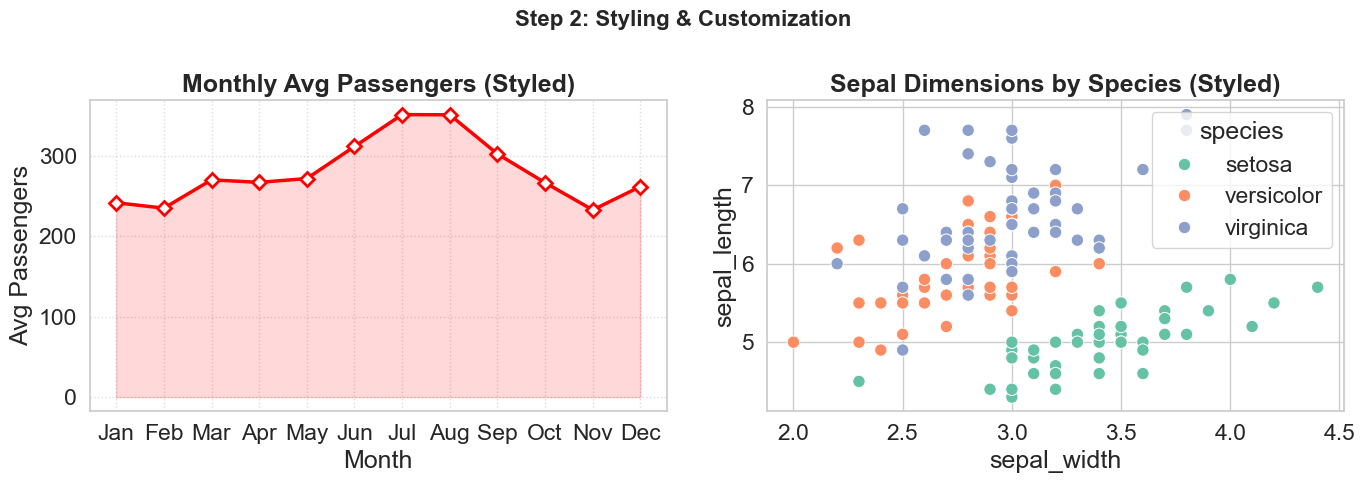

In [33]:
sns.set_theme(style = 'whitegrid' , palette='deep' , font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 2: Styling & Customization', fontsize=16, fontweight='bold')

# --- Styled Line Plot with custom palette ---
monthly =flights.groupby('month')['passengers'].mean().reset_index()
axes[0].plot(monthly['month'], monthly['passengers'],
            color='red', linewidth=2.5, marker='D',
            markersize=7, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(monthly['month'] , monthly['passengers'] , alpha=0.15 , color = 'red')
axes[0].set_title('Monthly Avg Passengers (Styled)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Passengers')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].set_facecolor('white')

# --- Styled Scatter with Seaborn palette ---
sns.scatterplot(data=iris , x='sepal_width', y='sepal_length',hue ='species', s =80 , palette='Set2' , ax= axes[1])
axes[1].set_title('Sepal Dimensions by Species (Styled)', fontweight='bold')
axes[1].set_facecolor('white')

plt.tight_layout()
plt.show()

## STEP3 : Distribution Plots

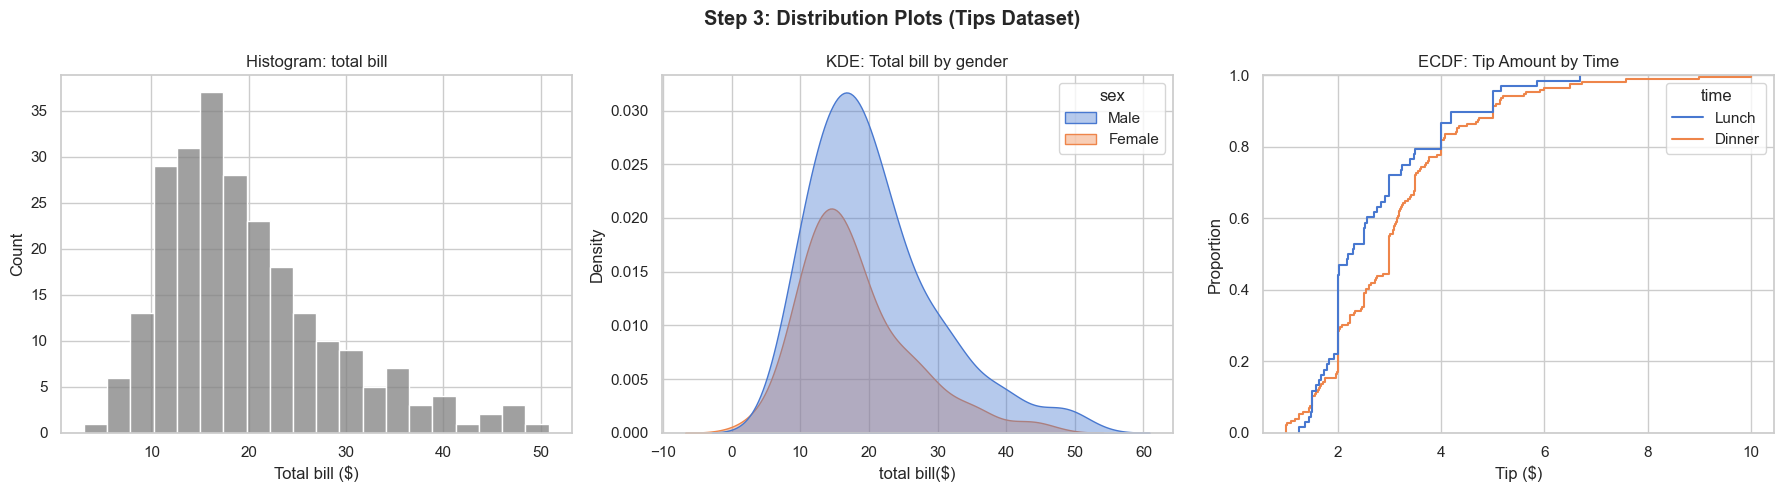

In [36]:
sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 3: Distribution Plots (Tips Dataset)', fontweight='bold')

# --- Histogram ---
sns.histplot(data=tips, x='total_bill', bins=20, kde=False,
            color='grey', ax=axes[0])
axes[0].set_title('Histogram: total bill')
axes[0].set_xlabel('Total bill ($)')

# --- KDE Plot ---
sns.kdeplot(data=tips ,x='total_bill' , hue='sex', fill=True ,alpha=0.4 , ax=axes[1])
axes[1].set_title('KDE: Total bill by gender')
axes[1].set_xlabel('total bill($)')

# --- ECDF Plot ---
sns.ecdfplot(data=tips ,x='tip' ,hue='time',ax=axes[2])
axes[2].set_title('ECDF: Tip Amount by Time')
axes[2].set_xlabel('Tip ($)')

plt.tight_layout()
plt.show()

## STEP4 : Categorical & Comparison Plots

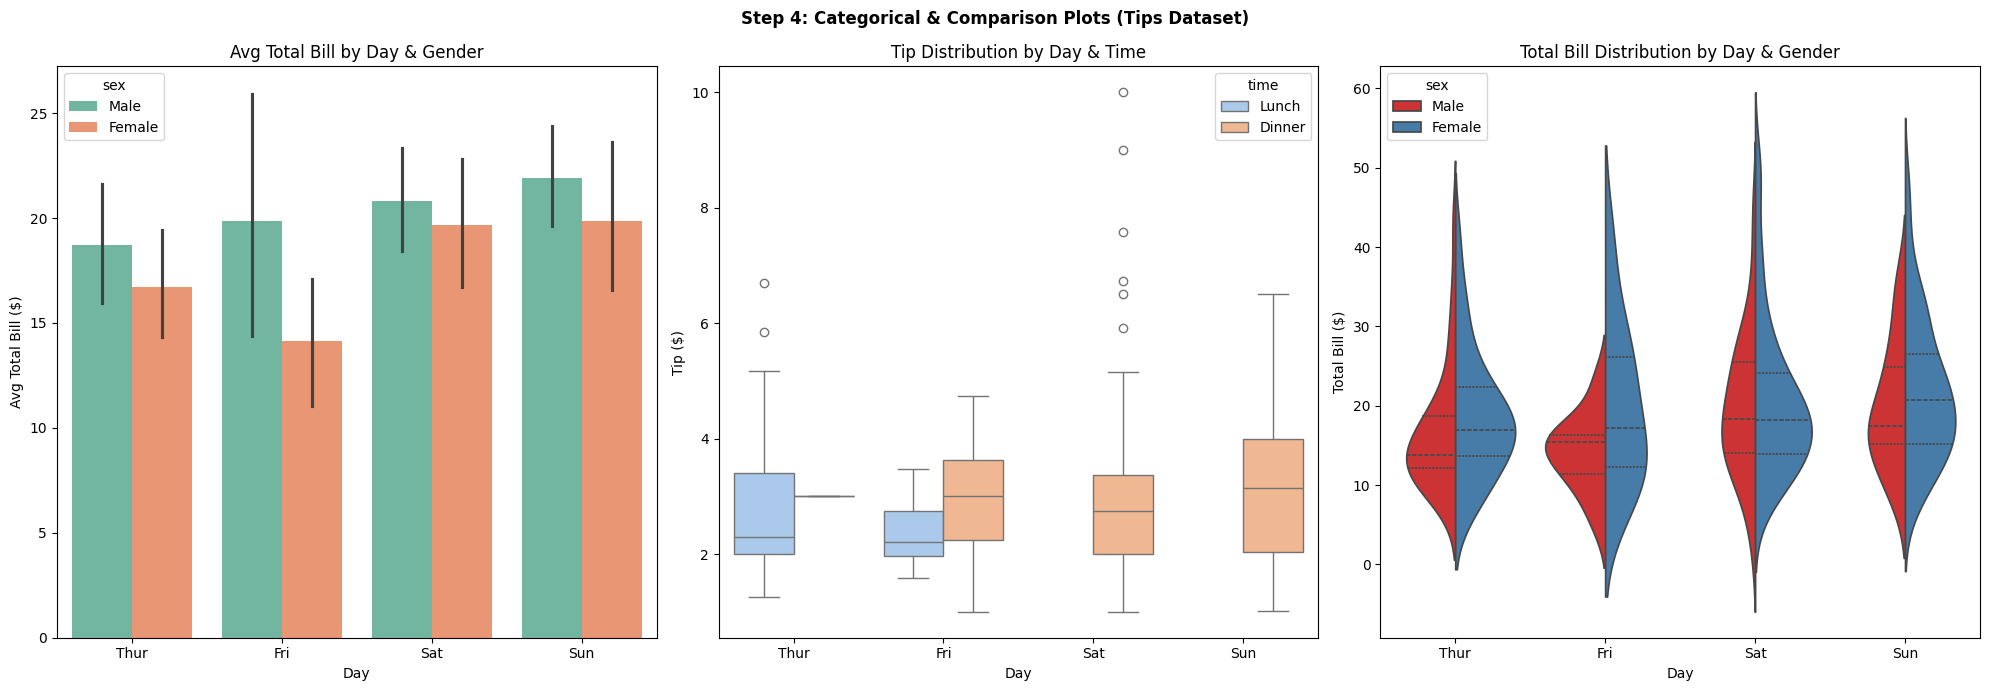

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Step 4: Categorical & Comparison Plots (Tips Dataset)', fontweight='bold')

# --- Bar Chart ---
sns.barplot(data=tips, x='day', y='total_bill', hue='sex',
            palette='Set2', ax=axes[0])
axes[0].set_title('Avg Total Bill by Day & Gender')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Avg Total Bill ($)')

# --- Box Plot ---
sns.boxplot(data=tips, x='day', y='tip', hue='time',
            palette='pastel', ax=axes[1])
axes[1].set_title('Tip Distribution by Day & Time')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Tip ($)')

# --- Violin Plot ---
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex',
                split=True, palette='Set1', inner='quart', ax=axes[2])
axes[2].set_title('Total Bill Distribution by Day & Gender')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Total Bill ($)')

plt.tight_layout()
plt.savefig('step4_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 5 : Heatmaps & Subplots

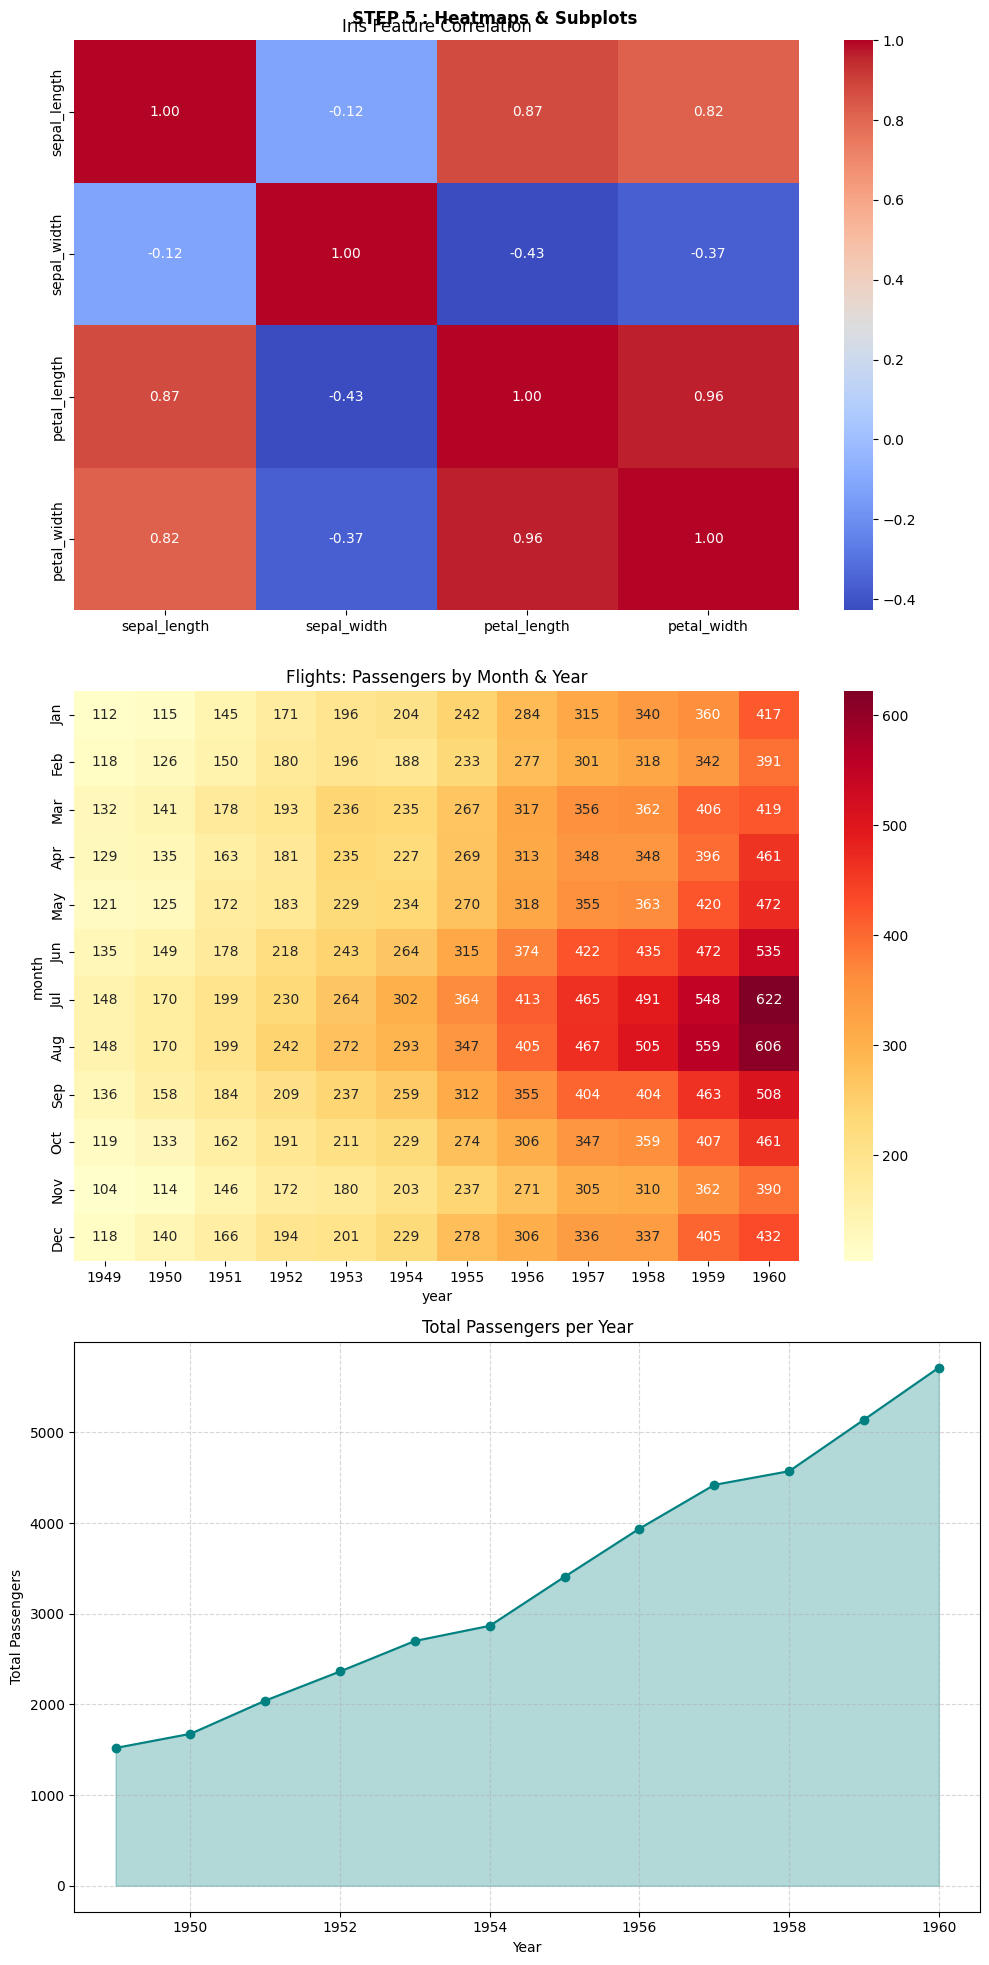

In [10]:
fig , axes =plt.subplots(3 , 1, figsize=(10, 20))
fig.suptitle('STEP 5 : Heatmaps & Subplots' ,fontweight='bold')

# --- Row 1: Iris correlation heatmap ---
iris_corr = iris.drop('species',axis=1).corr()
sns.heatmap(iris_corr, annot=True, fmt='.2f', cmap='coolwarm',ax=axes[0])
axes[0].set_title('Iris Feature Correlation')

# --- Row 2: Flights pivot heatmap ---
flights_pivot = flights.pivot(index='month' , columns='year' , values='passengers')
sns.heatmap(flights_pivot , annot=True , fmt="d" , cmap='YlOrRd' , ax=axes[1])
axes[1].set_title('Flights: Passengers by Month & Year')

# --- Row 3: Total passengers per year line ---
yearly=flights.groupby('year')['passengers'].sum()
axes[2].fill_between(yearly.index , yearly.values , alpha=0.3 , color='teal')
axes[2].plot(yearly.index, yearly.values, color='teal', marker='o')
axes[2].set_title('Total Passengers per Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Total Passengers')
axes[2].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Step 6 — Insights

**Line Plot:** Passengers grew steadily from 1949 to 1960, showing increasing aviation demand.

**Scatter Plot:** Setosa is clearly separated from other species based on petal length.

**Histogram:** Most bills fall between $10–$25, with a right-skewed distribution.

**KDE:** Males tend to have slightly higher total bills than females.

**ECDF:** Dinner tips are consistently higher than lunch tips.

**Bar Chart:** Saturday and Sunday have the highest average total bills.

**Box Plot:** Sunday has the most tip outliers across all days.

**Violin Plot:** Female bill amounts show less variance than Male amounts.

**Heatmap:** Petal length and petal width are strongly correlated (0.96).

**Flights Heatmap:** July and August are the busiest months every year.